# Insights Accionables - Paigo
**Autor:** Franco Robotti  
**Objetivo:** Destilar el análisis de los notebooks 00-02 en un conjunto de **insights accionables**: cada uno con su evidencia, su lectura de negocio y la **acción** concreta que propone.

> Parte de las tablas limpias de `../data/clean/`. Las consultas detalladas están en `02_sql_analitico`; aquí va el "¿y qué hacemos con esto?".

## Carga de datos

In [6]:
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
PALETA = "viridis"

CLEAN = "../data/clean"
df_clientes  = pd.read_excel(f"{CLEAN}/clientes_limpio.xlsx")
df_reviews   = pd.read_excel(f"{CLEAN}/reviews_limpio.xlsx")
df_bot       = pd.read_excel(f"{CLEAN}/bot_chats_limpio.xlsx")
df_productos = pd.read_excel(f"{CLEAN}/productos_limpio.xlsx")
df_reviews["fecha_review"] = pd.to_datetime(df_reviews["fecha_review"])
df_bot["fecha_inicio"]     = pd.to_datetime(df_bot["fecha_inicio"])
print("Datos cargados.")

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(exist_ok=True)

def guardar(nombre):
    """Guarda la figura actual en FIG_DIR con buena resolución."""
    plt.savefig(FIG_DIR / f"{nombre}.png", dpi=200, bbox_inches="tight")

Datos cargados.


## Insight 1 — El bot arrastra la satisfacción: CSAT muy por debajo del rating
Comparamos la satisfacción de la app (rating de reviews) con la del asistente (CSAT del bot), mes a mes.

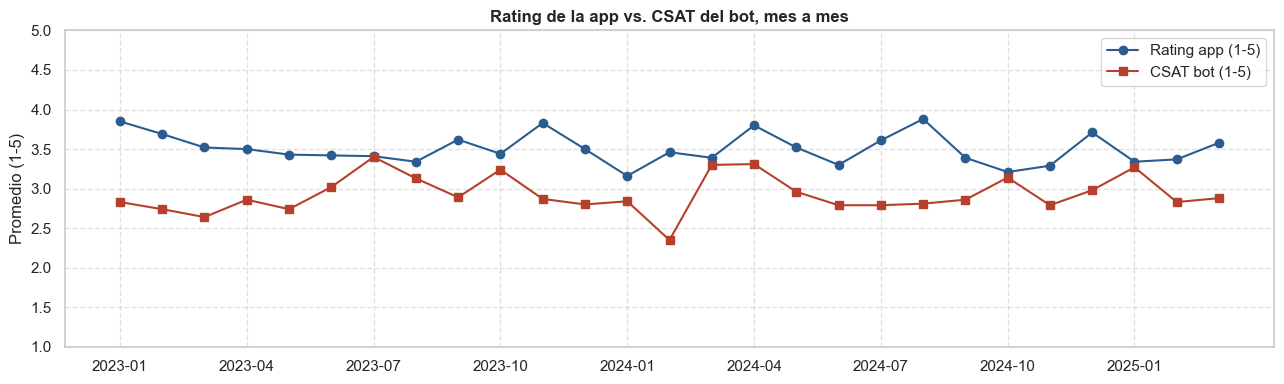

Rating promedio: 3.50  |  CSAT promedio: 2.94


In [7]:
evolucion = duckdb.query('''
WITH rating_mes AS (
    SELECT strftime(fecha_review, '%Y-%m') AS mes, ROUND(AVG(rating),2) AS rating
    FROM df_reviews GROUP BY 1),
csat_mes AS (
    SELECT strftime(fecha_inicio, '%Y-%m') AS mes, ROUND(AVG(csat_score),2) AS csat
    FROM df_bot GROUP BY 1)
SELECT r.mes, r.rating, c.csat
FROM rating_mes r LEFT JOIN csat_mes c ON r.mes = c.mes
ORDER BY r.mes
''').df()

plt.figure(figsize=(13, 4))
plt.plot(evolucion["mes"], evolucion["rating"], marker="o", label="Rating app (1-5)", color="#2b5c8f")
plt.plot(evolucion["mes"], evolucion["csat"], marker="s", label="CSAT bot (1-5)", color="#b5402b")
plt.title("Rating de la app vs. CSAT del bot, mes a mes")
plt.ylabel("Promedio (1-5)"); plt.xticks(evolucion["mes"][::3]); plt.ylim(1, 5)
plt.legend(); plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); 
guardar("03_evolucion_rating_csat_insights")
plt.show()

print(f"Rating promedio: {df_reviews['rating'].mean():.2f}  |  CSAT promedio: {df_bot['csat_score'].mean():.2f}")

**Hallazgo:** existe un **desacople de satisfacción**. El rating de la app se mantiene en **3.4–3.8**, pero el CSAT del bot queda muy por debajo, en **2.6–3.0**, y plano en el tiempo. La calidad percibida del producto ya superó a la capacidad de resolución del asistente.

**Acción:** priorizar la **reingeniería de los flujos del bot**, para que la experiencia de soporte esté a la altura del producto.

## Insight 2 — El cuello de botella del bot está en `consulta_tasa` y `onboarding_dudas`
Tasa de escalado a humano por tipo de consulta.

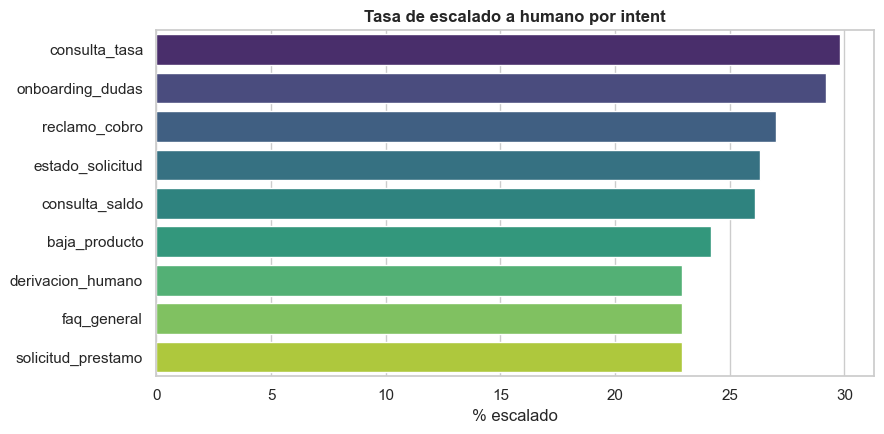

,intent_primario,chats,tasa_escalado
0,consulta_tasa,191,29.8
1,onboarding_dudas,401,29.2
2,reclamo_cobro,381,27.0
3,estado_solicitud,353,26.3
4,consulta_saldo,591,26.1
5,baja_producto,157,24.2
6,derivacion_humano,175,22.9
7,faq_general,376,22.9
8,solicitud_prestamo,375,22.9


In [9]:
escalado = duckdb.query('''
SELECT intent_primario,
       COUNT(*) AS chats,
       ROUND(100.0 * SUM(CASE WHEN escalado_humano = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS tasa_escalado
FROM df_bot GROUP BY 1 ORDER BY tasa_escalado DESC
''').df()

plt.figure(figsize=(9, 4.5))
sns.barplot(data=escalado, x="tasa_escalado", y="intent_primario",
            hue="intent_primario", palette=PALETA, legend=False)
plt.title("Tasa de escalado a humano por intent")
plt.xlabel("% escalado"); plt.ylabel("")
plt.tight_layout(); 
guardar("03_tasa_escalado_por_intent_insights")
plt.show()
escalado

**Hallazgo:** los intents que más derivan a un humano son **`consulta_tasa` (29.8%)** y **`onboarding_dudas` (29.2%)** — el bot no resuelve bien las dudas iniciales y las de tasas, sobrecargando a soporte humano.

> *Salvedad de calidad (notebook 01):* el campo `escalado_humano` es incoherente con `resolucion`, así que la tasa es un indicador aproximado. Conviene sanear ese registro.

**Acción:** **rediseñar los flujos del bot** para `consulta_tasa` y `onboarding_dudas` (mejor contenido de autoservicio en esos temas).

## Insight 3 — La insatisfacción de producto se concentra en la línea BNPL
% de reviews negativas (rating ≤ 2) por producto.

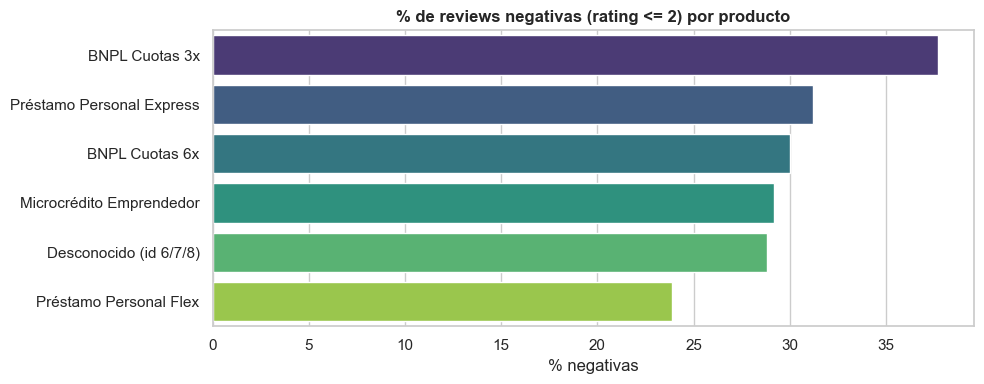

,producto,total,pct_negativas
0,BNPL Cuotas 3x,257,37.7
1,Préstamo Personal Express,295,31.2
2,BNPL Cuotas 6x,270,30.0
3,Microcrédito Emprendedor,284,29.2
4,Desconocido (id 6/7/8),805,28.8
5,Préstamo Personal Flex,289,23.9


In [10]:
prod_neg = duckdb.query('''
SELECT COALESCE(p.nombre_producto, 'Desconocido (id 6/7/8)') AS producto,
       COUNT(*) AS total,
       ROUND(100.0 * SUM(CASE WHEN r.rating <= 2 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_negativas
FROM df_reviews r
LEFT JOIN df_productos p
       ON r.id_producto = p.id_producto
GROUP BY 1 ORDER BY pct_negativas DESC
''').df()

plt.figure(figsize=(10, 4))
sns.barplot(data=prod_neg, x="pct_negativas", y="producto",
            hue="producto", palette=PALETA, legend=False)
plt.title("% de reviews negativas (rating <= 2) por producto")
plt.xlabel("% negativas"); plt.ylabel("")
plt.tight_layout(); 
guardar("03_pct_reviews_negativas_por_producto_insights")
plt.show()
prod_neg

**Hallazgo:** **`BNPL Cuotas 3x` es el producto más conflictivo (37.7%** de reviews negativas), seguido de `Préstamo Personal Express` (31.2%) y `BNPL Cuotas 6x` (30.0%). Además, las **805 reviews "Desconocido"** apuntan a 3 productos que faltan en el catálogo (detectado en el notebook 01).

**Acción:** poner foco de producto/soporte en la **línea BNPL**, y **recuperar los 3 productos faltantes** del catálogo para no perder visibilidad sobre un tercio de las reviews.

## Insight 4 — El promedio por canal engaña: el riesgo real es la doble insatisfacción
El rating promedio por canal es casi idéntico, pero esconde un segmento crítico en la cola.

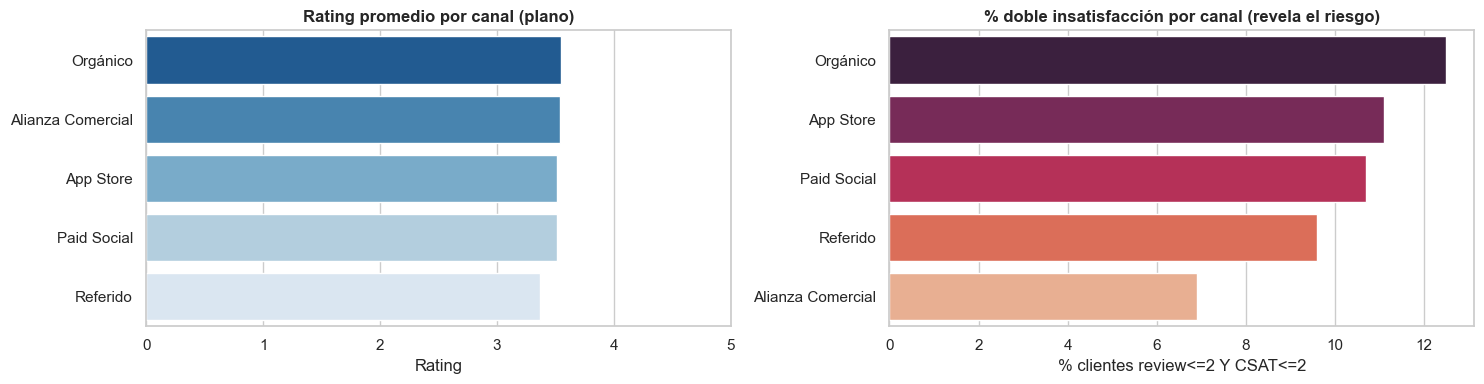

,canal_adquisicion,rating_prom
0,Orgánico,3.55
1,Alianza Comercial,3.54
2,App Store,3.51
3,Paid Social,3.51
4,Referido,3.37


,canal_adquisicion,pct_doble_insat
0,Orgánico,12.5
1,App Store,11.1
2,Paid Social,10.7
3,Referido,9.6
4,Alianza Comercial,6.9


In [11]:
rating_canal = duckdb.query('''
SELECT c.canal_adquisicion, ROUND(AVG(r.rating),2) AS rating_prom
FROM df_reviews r JOIN df_clientes c ON r.id_cliente = c.id_cliente
GROUP BY 1 ORDER BY rating_prom DESC
''').df()

doble = duckdb.query('''
WITH rmala AS (SELECT DISTINCT id_cliente FROM df_reviews WHERE rating <= 2),
     cmalo AS (SELECT DISTINCT id_cliente FROM df_bot WHERE csat_score <= 2)
SELECT c.canal_adquisicion,
       ROUND(100.0 * COUNT(DISTINCT CASE WHEN rm.id_cliente IS NOT NULL AND cm.id_cliente IS NOT NULL
                    THEN c.id_cliente END) / COUNT(DISTINCT c.id_cliente), 1) AS pct_doble_insat
FROM df_clientes c
LEFT JOIN rmala rm ON c.id_cliente = rm.id_cliente
LEFT JOIN cmalo cm ON c.id_cliente = cm.id_cliente
GROUP BY 1 ORDER BY pct_doble_insat DESC
''').df()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=rating_canal, x="rating_prom", y="canal_adquisicion",
            hue="canal_adquisicion", palette="Blues_r", legend=False, ax=axes[0])
axes[0].set_title("Rating promedio por canal (plano)"); axes[0].set_xlim(0,5)
axes[0].set_xlabel("Rating"); axes[0].set_ylabel("")
sns.barplot(data=doble, x="pct_doble_insat", y="canal_adquisicion",
            hue="canal_adquisicion", palette="rocket", legend=False, ax=axes[1])
axes[1].set_title("% doble insatisfacción por canal (revela el riesgo)")
axes[1].set_xlabel("% clientes review<=2 Y CSAT<=2"); axes[1].set_ylabel("")
plt.tight_layout(); 
guardar("03_rating_y_doble_insatisfaccion_por_canal_insights")
plt.show()
display(rating_canal, doble)

**Hallazgo:** el rating por canal es **plano (3.37–3.55)**: la media no discrimina. Pero al cruzar reviews y CSAT, **`Orgánico` (12.5%)** y **`Paid Social` (10.7%)** concentran a los clientes **doblemente insatisfechos** — ~160 clientes en total. `Orgánico` tenía el *mejor* rating promedio y a la vez el peor segmento oculto.

**Acción:** lanzar una **campaña de retención dirigida** a los clientes en riesgo de `Orgánico` y `Paid Social` (push / email / WhatsApp), que son los canales de mayor volumen.

## Síntesis de insights accionables

| # | Hallazgo | Evidencia | Acción |
|:-:|:---|:---|:---|
| 1 | El bot arrastra la satisfacción | CSAT 2.6–3.0 < rating 3.4–3.8 | Reingeniería de flujos del bot |
| 2 | Cuello de botella del bot | `consulta_tasa` 29.8% y `onboarding_dudas` 29.2% escalan | Rediseñar esos flujos / autoservicio |
| 3 | Insatisfacción de producto en BNPL | BNPL Cuotas 3x: 37.7% reviews negativas | Foco en BNPL + recuperar catálogo |
| 4 | El promedio de canal engaña | Doble insatisfacción: Orgánico 12.5%, Paid Social 10.7% | Campaña de retención dirigida |

**Insight principal para negocio:** la satisfacción promedio luce sana, pero hay un segmento de ~160 clientes (10.7%) doblemente insatisfechos, concentrado en los canales de mayor volumen y con el bot como principal foco de fricción. Atacar el bot (calidad) y retener ese segmento (engagement) son las dos palancas de mayor impacto.